In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/glass/glass.csv


In [2]:
path='/kaggle/input/glass/glass.csv'

In [3]:
df= pd.read_csv(path)

In [4]:
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [7]:
pd.unique(df['Type'])

array([1, 2, 3, 5, 6, 7])

In [11]:
df['Window']=df['Type'].map({1:0,2:0,3:0,4:0, 5:1,6:1,7:1})

In [23]:
df = df.drop(columns=['Type'])

In [12]:
df['Window'].values

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [24]:
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Window
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,0
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,1
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,1
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,1
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,1


In [25]:
#reshape and drop
X = df.drop(columns=['Window']).values
y = df['Window'].values.reshape(-1,1)

In [27]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [28]:
#split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [32]:
#Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [33]:
#slpnn
class SLPNN:
    def __init__(self, input_size, lr=0.001):
        self.w = np.random.randn(input_size, 1) * 0.01
        self.eta = lr
        self.E = []

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def feedforward(self, X):
        z = np.dot(X, self.w)
        return self.sigmoid(z)

    def error(self, h, y):
        # Cross-entropy loss
        error = -np.mean(y*np.log(h + 1e-9) + (1 - y)*np.log(1 - h + 1e-9))
        self.E.append(error)

    def backprop(self, X, y, h):
        dw = np.dot(X.T, (h - y)) / X.shape[0]
        self.w -= self.eta * dw

    def train(self, X, y, epochs=10000):
        for epoch in range(epochs):
            h = self.feedforward(X)
            self.error(h, y)
            self.backprop(X, y, h)

    def predict(self, X):
        return self.feedforward(X)

    def classify(self, X, threshold=0.5):
        return (self.predict(X) >= threshold).astype(int)

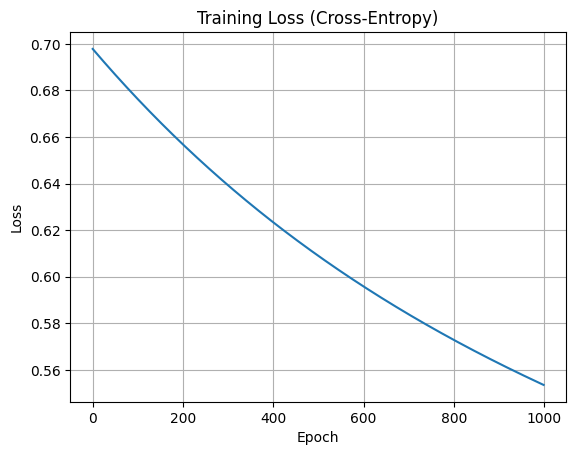

In [67]:
# Train Model

model = SLPNN(input_size=X_train.shape[1], lr=0.001)

model.train(X_train, y_train, epochs=1000)

# Plot training loss
plt.plot(model.E)
plt.title("Training Loss (Cross-Entropy)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [68]:
#  Evaluate on Test

y_pred_proba = model.predict(X_test)
y_pred_class = model.classify(X_test)

accuracy = np.mean(y_pred_class == y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Inspect final weights
print("Final Weights:\n", model.w)

Test Accuracy: 93.02%
Final Weights:
 [[-0.04435876]
 [ 0.12478407]
 [-0.23251498]
 [ 0.17492046]
 [ 0.05205053]
 [ 0.04343651]
 [ 0.01405194]
 [ 0.15939622]
 [-0.0544388 ]]


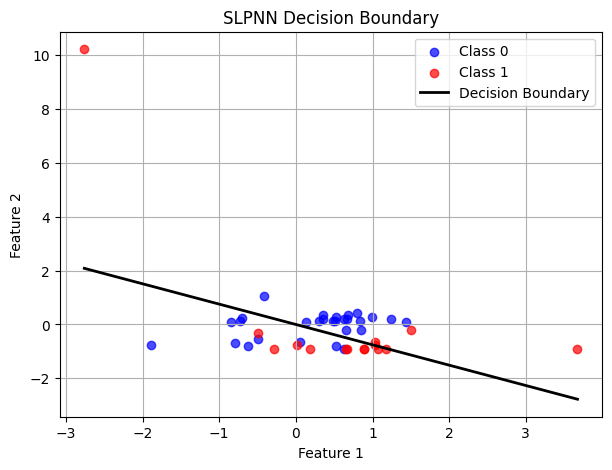

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


X_plot = X_test[:, [4, 5]]      # take feature 0 and 1
y_plot = y_test.flatten()


w1 = model.w[0, 0]
w2 = model.w[1, 0]



x_vals = np.linspace(X_plot[:, 0].min(), X_plot[:, 0].max(), 100)
y_vals = -(w1 * x_vals) / w2


plt.figure(figsize=(7,5))

plt.scatter(X_plot[y_plot == 0, 0],
            X_plot[y_plot == 0, 1],
            color='blue', label='Class 0', alpha=0.7)

plt.scatter(X_plot[y_plot == 1, 0],
            X_plot[y_plot == 1, 1],
            color='red', label='Class 1', alpha=0.7)

plt.plot(x_vals, y_vals, color='black', linewidth=2, label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('SLPNN Decision Boundary')
plt.legend()
plt.grid(True)
plt.show()
